In [4]:
import pandas as pd
df = pd.read_csv('student_performance.csv')

# Data wala mul row 5 balamu
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


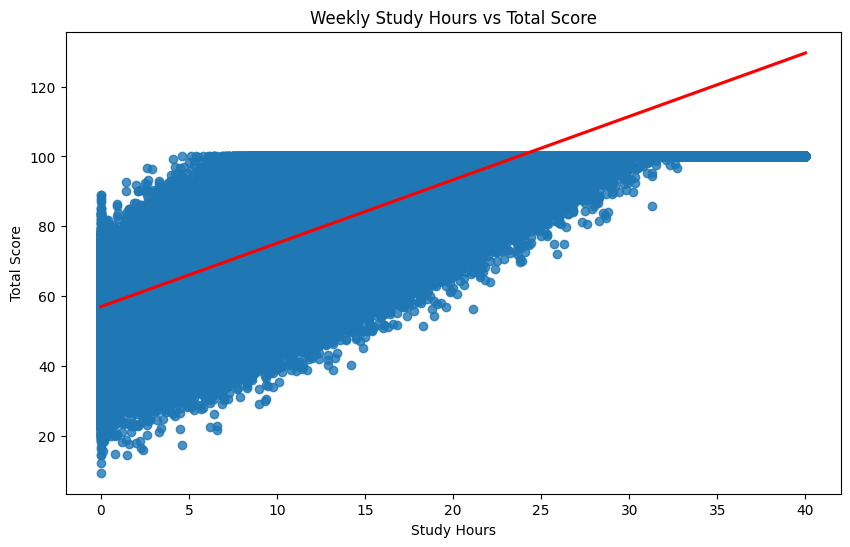

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Study hours saha Total Score athara sambandaya balamu
plt.figure(figsize=(10, 6))
sns.regplot(x='weekly_self_study_hours', y='total_score', data=df, line_kws={"color": "red"})
plt.title('Weekly Study Hours vs Total Score')
plt.xlabel('Study Hours')
plt.ylabel('Total Score')
plt.show()

In [6]:
# Wadak nathi columns ain karamu
df_cleaned = df.drop(['student_id', 'grade'], axis=1)

# Dan data thiyena hati balamu
print(df_cleaned.head())

# Check if there are any empty (null) values
print("\nMissing values check:")
print(df_cleaned.isnull().sum())

   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     18.5                   95.6                  3.8   
1                     14.0                   80.0                  2.5   
2                     19.5                   86.3                  5.3   
3                     25.7                   70.2                  7.0   
4                     13.4                   81.9                  6.9   

   total_score  
0         97.9  
1         83.9  
2        100.0  
3        100.0  
4         92.0  

Missing values check:
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

# Features (Api predict karanna use karana dewal)
X = df_cleaned.drop('total_score', axis=1)

# Target (Api predict karanna ona de)
y = df_cleaned['total_score']

# Data bedamu (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (800000, 3)
Testing data size: (200000, 3)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Model eka create karamu
model = LinearRegression()


In [9]:
# 2. Model ekata data deela train karamu
model.fit(X_train, y_train)


LinearRegression()

In [10]:
# 3. Predict karala balamu (Exam eka thiyamu)
predictions = model.predict(X_test)


In [11]:
# 4. Accuracy eka balamu
print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("R2 Score (Accuracy):", r2_score(y_test, predictions))

Mean Absolute Error: 7.161333476729997
R2 Score (Accuracy): 0.6600425865640975
